# LangSmith Demo

**Project:** LLM Museum Description Generator


## Agenda
1) Observability & Tracing: `@traceable`, LangGraph, metadata & filtering
2) Prompt Engineering: prompt playground, prompt hub, and canvas. 
3) Testing & Evaluating: debugging, datasets, rule evaluators, LLM-as-judge, and annotation queues. 
4) Monitoring & Improvements: online evals, automations, and dashboards.


In [87]:

# Load env
from dotenv import load_dotenv
load_dotenv()
import os
import warnings
warnings.filterwarnings("ignore") 
LANGSMITH_API_KEY =
os.getenv("LANGSMITH_API_KEY")
LANGCHAIN_API_KEY = os.getenv("LANGCHAIN_API_KEY")
LANGCHAIN_TRACING_v2 = os.getenv("LANGCHAIN_TRACING_v2")
PROJECT = os.getenv("LANGCHAIN_PROJECT")
print("Project: ", PROJECT)



Project:  langsmith-demo-0


## 1) Observability & tracing: Simple Museum Label LLM Application

![Simple LLM App](images/museum-app.jpg)

### Using the @traceable decorator, metadata, run types:

In [ ]:
"""
Fetch context from Wikipedia, then prompt an LLM to write a museum label.
Traced with LangSmith. Uses LangChain's `Document` type end-to-end.
"""

from typing import List, Tuple
import nest_asyncio
from langsmith import traceable
from openai import OpenAI

# LangChain bits
from langchain.docstore.document import Document
from langchain_community.document_loaders import WikipediaLoader



# ---- config ----
DEFAULT_MODEL = "gpt-4o-mini"
DEFAULT_TEMPERATURE = 0.2
WIKI_LANG = "en"
WIKI_MAX_DOCS = 2  # pull 1–2 short articles/snippets

MUSEUM_SYSTEM_PROMPT = """You are a museum label writer.
Write a concise (150–200 words), public-facing label for the given artwork using only the provided context.
Be concise, scholarly, and elegant; avoid jargon or define it briefly.
If context is insufficient, say so briefly."""


# ---- init ----
nest_asyncio.apply()
openai_client = OpenAI()

# -------------------------------------------------
# 1) Retrieve context from Wikipedia
# -------------------------------------------------
@traceable(run_type="retriever", metadata={"source": "wikipedia"})
def retrieve_wikipedia(
    artwork_name: str,
    lang: str = WIKI_LANG,
    max_docs: int = WIKI_MAX_DOCS
) -> List[Document]:
    """Fetch short context snippets from Wikipedia for an artwork."""
    loader = WikipediaLoader(query=artwork_name, lang=lang, load_max_docs=max_docs)
    docs = loader.load()
    for d in docs:
        title = d.metadata.get("title") or d.metadata.get("source") or artwork_name
        d.metadata["title"] = title
        d.metadata["source"] = f"Wikipedia:{title}"
    return docs

# -------------------------------------------------
# 2) Compose prompt messages
# -------------------------------------------------
@traceable(run_type="chain", metadata={"stage": "prompt_build"})
def build_messages(artwork_name: str, docs: List[Document]) -> List[dict]:
    """Builds the message list for the OpenAI chat API."""
    if not docs:
        user_content = (
            f"No reliable context found.\nArtwork: {artwork_name}\n"
            f"Write a brief public-facing label and note uncertainty."
        )
        return [
            {"role": "system", "content": MUSEUM_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

    context = "\n\n".join(d.page_content[:1500] for d in docs)
    user_content = (
        f"Artwork: {artwork_name}\n\n"
        f"Context (from Wikipedia):\n{context}\n\n"
        f"Write the label. If any details are uncertain, qualify them briefly."
    )
    return [
        {"role": "system", "content": MUSEUM_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

# -------------------------------------------------
# 3) Call OpenAI (LLM)
# -------------------------------------------------
@traceable(
    run_type="llm",
    metadata={
        "provider": "openai",
        "model": DEFAULT_MODEL,
        "temperature": DEFAULT_TEMPERATURE,
        "purpose": "museum_label_generation",
    },
)
def call_openai(
    messages: List[dict],
    model: str = DEFAULT_MODEL,
    temperature: float = DEFAULT_TEMPERATURE,
):
    """Executes the chat completion request to the OpenAI model."""
    return openai_client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temperature,
    )

# -------------------------------------------------
# 4) Orchestrator (Wikipedia ➜ LLM)
# -------------------------------------------------
@traceable(run_type="chain", metadata={"pipeline": "wikipedia_label", "version": "1.0"})
def museum_description_generator(artwork_name: str) -> Tuple[str, List[str]]:
    """Retrieves Wikipedia context and generates a museum label."""
    docs = retrieve_wikipedia(artwork_name)
    msgs = build_messages(artwork_name, docs)
    resp = call_openai(msgs)

    description = resp.choices[0].message.content
    return description

# ---- CLI ----
artwork = "The Birth of Venus"
description = museum_description_generator(artwork)

print("\n--- Museum Description ---\n")
print(description)

### Langgraph example: Out of the box tracing

Tracing V2: true
Project: langsmith-demo-0
Key set: True


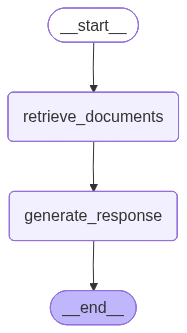


--- Museum Description ---

**The Birth of Venus**  
Sandro Botticelli  
c. 1484–1486  
Tempera on canvas  

In this iconic painting, Sandro Botticelli captures the moment of Venus's arrival on the shore, emerging from the sea in a giant scallop shell. The goddess, depicted in a state of graceful nudity, is propelled by the wind gods Zephyrus and Aura, who blow her towards the land, symbolizing beauty and love. To the right, a figure representing one of the Horae, or goddesses of the seasons, awaits to drape Venus in a rich cloak, embodying the themes of renewal and fertility.

Botticelli's work stands as a hallmark of the Italian Renaissance, celebrated for its lyrical beauty and mythological depth. The painting's composition and scale were unprecedented in Western art since antiquity, showcasing the artist's mastery in rendering the human form and evoking emotion. While its title, "The Birth of Venus," was assigned later, the scene illustrates a pivotal moment in the goddess's narra

In [90]:
import nest_asyncio
import operator
import os
from typing import List
from typing_extensions import TypedDict, Annotated

from langchain_core.messages import HumanMessage, AnyMessage, get_buffer_string
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# LangChain docs + retriever
from langchain.docstore.document import Document
from langchain_community.retrievers import WikipediaRetriever  # emits retriever runs

nest_asyncio.apply()

# --- sanity print like the example ---
print("Tracing V2:", os.getenv("LANGCHAIN_TRACING_v2"))
print("Project:", os.getenv("LANGCHAIN_PROJECT"))
print("Key set:", bool(os.getenv("LANGCHAIN_API_KEY")))

# ---- config ----
DEFAULT_MODEL = "gpt-4o-mini"
DEFAULT_TEMPERATURE = 0.2
WIKI_MAX_DOCS = 2
retriever = WikipediaRetriever(top_k_results=WIKI_MAX_DOCS)
llm = ChatOpenAI(model=DEFAULT_MODEL, temperature=DEFAULT_TEMPERATURE)

# Prompt text 
MUSEUM_PROMPT = """You are a museum label writer.

Write a concise (150–200 words), public-facing label for the given artwork using only the provided context.
Be concise, scholarly, and elegant; avoid jargon or define it briefly. If context is insufficient, say so briefly.

Artwork: {question}

Context (from Wikipedia):
{context}

Write the label. If any details are uncertain, qualify them briefly.
"""

# -------- Graph state (match the clean example's shape) --------
class GraphState(TypedDict):
    question: str
    messages: Annotated[List[AnyMessage], operator.add]
    documents: List[Document]

# -------- Nodes --------
def retrieve_documents(state: GraphState):
    messages = state.get("messages", [])
    question = state["question"]
    # Use conversation buffer + query (mirrors the example)
    query = f"{get_buffer_string(messages)} {question}".strip()
    documents = retriever.invoke(query)  # <- LangChain retriever => shows 'retriever' run
    return {"documents": documents}

def generate_response(state: GraphState):
    question = state["question"]
    messages = state.get("messages", [])
    documents = state.get("documents", [])

    context = "\n\n".join(doc.page_content for doc in documents) if documents else \
              f"No reliable context found for '{question}'."

    prompt_text = MUSEUM_PROMPT.format(context=context, question=question)
    generation = llm.invoke([HumanMessage(content=prompt_text)])  # <- shows 'llm' run
    return {"documents": documents, "messages": [HumanMessage(question), generation]}

# -------- Build the graph --------
graph_builder = StateGraph(GraphState)
graph_builder.add_node("retrieve_documents", retrieve_documents)
graph_builder.add_node("generate_response", generate_response)

graph_builder.add_edge(START, "retrieve_documents")
graph_builder.add_edge("retrieve_documents", "generate_response")
graph_builder.add_edge("generate_response", END)

museum_graph = graph_builder.compile()

try:
    display(Image(museum_graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

# -------- Simple CLI --------
if __name__ == "__main__":
    out = museum_graph.invoke({"question": "The Birth of Venus", "messages": []})
    msgs = out.get("messages", [])
    label = msgs[-1].content if msgs else ""
    print("\n--- Museum Description ---\n")
    print(label)


### Additional Tracing Resources: 

- [OpenAI wrapper: wrap_openai](https://docs.smith.langchain.com/reference/python/wrappers/langsmith.wrappers._openai.wrap_openai) 
- [Conversational tracing](https://docs.smith.langchain.com/reference/python/wrappers/langsmith.wrappers._openai.wrap_openai) 
- [Trace context manager](https://docs.smith.langchain.com/reference/python/run_helpers/langsmith.run_helpers.trace)
- [LangGraph Studio](https://langchain-ai.github.io/langgraphjs/concepts/langgraph_studio/) 

## 2) Prompt Engineering: prompt hub, templates, and canvas

### Pulling prompt template from prompthub

In [108]:
from typing import List, Tuple
from langsmith import Client, traceable
from langchain.docstore.document import Document
from langchain_community.document_loaders import WikipediaLoader

client = Client()  

def museum_caption_generator(artwork: str, audience: str, prompt):
    @traceable(run_type="llm", name="generate_label", metadata={
        "provider": "openai",
        "model": DEFAULT_MODEL,
        "temperature": DEFAULT_TEMPERATURE,
        "purpose": "museum_label_generation",
    },)
    
    def generate_label(artwork: str, docs: List[Document], audience: str = "general public") -> str:
        context = "\n\n".join(d.page_content[:1500] for d in docs) if docs else ""
        result = prompt.invoke({"artwork": artwork, "context": context, "audience": audience})
        return getattr(result, "content", str(result))

    @traceable(run_type="retriever", name="retrieve_wikipedia")
    def retrieve_wikipedia(artwork: str, lang: str = "en", max_docs: int = 2) -> List[Document]:
        docs = WikipediaLoader(query=artwork, lang=lang, load_max_docs=max_docs).load()
        for d in docs:
            t = d.metadata.get("title") or d.metadata.get("source") or artwork
            d.metadata["title"] = t
            d.metadata["source"] = f"Wikipedia:{t}"
        return docs

    @traceable(run_type="chain", name="museum_label_from_wikipedia")
    def museum_label_from_wikipedia(artwork: str, audience: str = "general public") -> Tuple[str, List[str]]:
        docs = retrieve_wikipedia(artwork)
        label = generate_label(artwork, docs, audience)
        cites = [d.metadata.get("source", "Wikipedia") for d in docs] if docs else []
        return label

    return museum_label_from_wikipedia(artwork, audience)

#TODO: Pull prompt here
# prompt = client.pull_prompt("simple-museum-prompt:84cd00b2", include_model=True)
prompt = client.pull_prompt("art-only-prompt:485a79ff", include_model=True)

artwork = "The Birth of Venus"
audience = "general public"

print(museum_caption_generator(artwork, audience, prompt))


The title The Birth of Venus names two celebrated paintings with very different artistic voices.

Sandro Botticelli’s mid-1480s work (Uffizi, Florence) renders the goddess emerging from the sea in a fragile, lyrical manner. Painted on a large scale uncommon for mythological scenes of its day, it places a prominently nude female figure at the center, recalling ancient imagery (Venus Anadyomene). Botticelli’s composition and linear grace give the scene an almost sculptural purity; the effect is one of poised serenity rather than overt narrative complexity.

Alexandre Cabanel’s 1863 canvas (Musée d’Orsay, Paris) offers a contrasting 19th‑century vision. Bathed in opalescent color, his Venus reclines with a coy, ambiguous gaze—eyes that appear both asleep and awake—inviting a sensual, dreamlike response. Cabanel emphasizes polished finish and soft modeling to heighten tactile allure; his palette and delicate brushwork create an ethereal, modernized classicism that hovers between antiquity 

## 3) Testing & Evaluating: datasets, offiline evaluators, LLM-as-judge, and annotation queues

![Evaluation Lifecycle](images/evaluation_lifecycle.png)

### Loading a dataset

In [ ]:
GOLDEN_EXAMPLES = [
    (
        "The Starry Night",
        "general public",
        """Vincent van Gogh painted The Starry Night in 1889 while staying at an asylum in Saint-Rémy, in southern France.
Thick, swirling strokes of blue, yellow, and white turn the night sky into a living current that seems to pulse above a quiet village.
The cypress at left rises like a dark flame, linking earth and sky. Van Gogh did not record the view exactly as he saw it; the village is imagined, and the bold rhythms
of paint carry his emotional response to nature more than a literal description. The work reflects van Gogh’s intense study of color and his belief that brushwork could express
inner feeling—an idea that helped shape modern art. Although the picture suggests turbulence, it is carefully structured: sweeping arcs lead the eye across the canvas, and constellations
anchor the composition. This painting invites us to feel the night not as empty darkness but as a vibrant, moving space filled with light and energy."""
    ),
    (
        "Mona Lisa",
        "general public",
        """Leonardo da Vinci’s Mona Lisa (about 1503–6) is among the most studied portraits in Western art.
The sitter—likely Lisa Gherardini, a Florentine merchant’s wife—meets the viewer with a famously subtle smile.
Leonardo achieves this effect through sfumato, the delicate blending of tones that softens edges around the mouth and eyes,
making the expression appear to shift with our gaze. The atmospheric landscape behind her recedes through layers of blue, a demonstration of
Leonardo’s interest in optics and the behavior of light. The three-quarter pose, turned slightly toward us, was innovative for its time and has
become a standard in portraiture. Painted with extraordinary finesse on poplar, the panel rewards close looking: the sitter’s folded hands convey calm dignity,
and the carefully modeled face suggests an inner life rather than a status display. The picture’s fame owes not only to its history, but to the way it balances
observed detail with mystery, inviting endless interpretation."""
    ),
    (
        "The Birth of Venus",
        "general public",
        """Sandro Botticelli’s The Birth of Venus (late 1480s) imagines the goddess arriving at the shore, carried on a shell by the wind.
The scene draws on ancient poetry and the Renaissance revival of classical mythology. Venus’s modest pose recalls antique sculpture,
yet the painting’s graceful contours and flowing hair are distinctly Botticelli’s—more lyrical than naturalistic. Executed with tempera on canvas,
an unusual support for Florence at the time, the work may have adorned a domestic interior connected with the Medici circle.
Viewers in the fifteenth century could read the image on several levels: as a charming myth, as a celebration of beauty’s civilizing power,
and, in Neoplatonic terms, as a metaphor for divine love entering the world. The idealized shore and rhythmic lines create a harmonious, almost musical surface.
Rather than presenting a literal event, Botticelli offers a poetic vision, inviting us to reflect on how art transforms stories into enduring images."""
    ),
    (
        "Girl with a Pearl Earring",
        "general public",
        """Johannes Vermeer’s Girl with a Pearl Earring (about 1665) is not a formal portrait but a “tronie”—a study of an expressive figure in exotic dress.
The young woman turns toward us as if surprised, lips parted, eyes bright. Light falls gently across her face and glints on the oversized pearl,
a simple device that anchors the composition. Vermeer’s restrained palette—deep blues, warm ochers, and soft flesh tones—heightens the sense of intimacy.
We do not know the sitter’s identity, and the turban was not common Dutch attire; both choices invite curiosity rather than biography.
The smooth surface and subtle transitions of tone reveal Vermeer’s mastery of optical effects, perhaps informed by close looking through lenses.
Stripped of narrative detail, the painting focuses on a moment of encounter between viewer and subject. Its quiet power lies in how little it tells us:
the work suggests personality and presence without fixing them, leaving room for our imagination."""
    ),
    (
        "The Persistence of Memory",
        "general public",
        """In The Persistence of Memory (1931), Salvador Dalí gives the solidity of clocks a dreamlike instability.
Pocket watches soften and slump across a barren landscape, their hands still marking time even as the metal seems to melt.
A pale, sleeping head at center—often read as a self-referential form—adds to the uncanny mood. Dalí, a leading Surrealist,
used meticulously realistic technique to render irrational scenes, capturing the logic of dreams where familiar objects behave in unfamiliar ways.
The ants and fly suggest decay and the irritation of time’s passage. The rocky background refers to the coast of Catalonia, grounding fantasy in a real place.
Rather than proposing a single meaning, the painting prompts us to consider how memory stretches and compresses experience.
By making time itself appear fluid, Dalí transforms an everyday instrument into a symbol of the mind’s elastic, subjective world."""
    ),
    (
        "Guernica",
        "general public",
        """Pablo Picasso painted Guernica in 1937 in response to the bombing of the Basque town during the Spanish Civil War.
The vast canvas, rendered in blacks, whites, and grays, rejects color to emphasize the starkness of the tragedy.
Fragmented figures—a screaming mother with her dead child, a gored horse, a fallen warrior—convey grief and chaos without literal storytelling.
Picasso drew on both modern Cubist fracture and classical motifs, such as the bull, to create a universal image of civilian suffering.
The electric light overhead reads as both a bulb and an unblinking eye, amplifying the sense of exposure.
Guernica is not a battlefield scene; it is a cry against the violence that reaches into homes and streets.
Its enduring power comes from the tension between distance and immediacy: the abstracted forms resist sensational detail, yet the emotion is unmistakable."""
    ),
    (
        "The Night Watch",
        "general public",
        """Rembrandt’s so-called Night Watch (1642) actually depicts a daytime departure of a civic militia company led by Captain Frans Banning Cocq.
The popular title arose later when darkened varnish made the scene seem nocturnal. Rembrandt animates what could have been a static group portrait:
figures stride, turn, and interact as light cuts across the crowd, spotlighting the captain in black and his lieutenant in yellow.
The little girl with a chicken—perhaps a symbol of the company—adds a flash of mystery and movement. Rembrandt’s mastery of chiaroscuro
creates depth and drama, while the diagonals of spears and banners guide the eye. Painted at a monumental scale,
the work celebrates civic pride as much as individual likeness. It invites viewers to experience the energy of Amsterdam’s guardsmen
at the height of the Dutch Golden Age."""
    ),
    (
        "The Last Supper",
        "general public",
        """Leonardo da Vinci’s Last Supper (about 1495–98) captures the moment Christ tells the apostles that one of them will betray him.
Seated along one side of a long table, the figures react in groups of three, their gestures and expressions revealing shock, doubt, and inquiry.
Leonardo used linear perspective to draw the architecture toward a vanishing point behind Christ’s head, clarifying his central role.
Painted on the refectory wall of Santa Maria delle Grazie in Milan, the work combines experimental technique with careful observation,
which sadly contributed to its early deterioration. Despite losses and restorations, the composition remains compelling:
it is less a narrative snapshot than a study of human response. The quiet triangle of Christ’s body contrasts with the rising motion around him,
inviting contemplation of betrayal and forgiveness."""
    ),
    (
        "The Scream",
        "general public",
        """Edvard Munch’s The Scream (first version 1893) transforms a personal sense of anxiety into a universal image.
A figure on a bridge presses hands to its face as the sky ripples in bands of red, orange, and blue.
Munch described experiencing “a great, infinite scream through nature,” and he translated that sensation into undulating lines and bold color.
Several versions exist—paintings, pastels, prints—each exploring the theme. The landscape likely overlooks Oslofjord, but the scene is more emotional than geographic.
Perspective tilts, and the railing thrusts diagonally across the picture, intensifying the figure’s isolation.
Rather than depict a specific event, Munch gives form to a feeling that many viewers recognize, making the painting a landmark of Expressionism."""
    ),
    (
        "The Great Wave off Kanagawa",
        "general public",
        """Katsushika Hokusai’s The Great Wave off Kanagawa (about 1831) is a woodblock print from the series Thirty-Six Views of Mount Fuji.
A towering wave curls into sharp claws, about to crash over fishing boats, while the distant mountain remains calm and triangular.
Hokusai used imported Prussian blue to achieve intense, layered color, and he combined traditional ukiyo-e techniques with a fresh sense of space.
The print captures both the drama of the sea and the endurance of those who work on it. Its bold design and asymmetrical composition
influenced many European artists in the late nineteenth century, contributing to the Japonisme movement. The image remains a global icon of nature’s power."""
    ),
    (
        "Las Meninas",
        "general public",
        """Diego Velázquez’s Las Meninas (1656) is a court scene that complicates who is looking at whom.
The painter includes himself at left, brush in hand, while the young Infanta Margarita stands among her attendants.
A mirror at the back reflects the king and queen, suggesting they stand where we do, outside the picture.
The composition plays with space, status, and the act of painting itself: is this a portrait, a studio view, or both?
Velázquez’s loose, luminous brushwork brings life to textures of fabric and hair, while the restrained palette keeps attention on light and presence.
The painting invites us into a moment that feels spontaneous yet carefully arranged, making viewers collaborators in the scene."""
    ),
    (
        "Liberty Leading the People",
        "general public",
        """Eugène Delacroix painted Liberty Leading the People (1830) after the July Revolution in Paris.
The allegorical figure of Liberty strides over barricades, holding the tricolor flag and a musket, while citizens from different walks of life rally behind her.
Smoke and rubble set the scene of urban conflict; warm, broken brushwork conveys urgency and movement.
The painting blends reportage with symbolism: Liberty is an idea made visible, at once a real participant and a timeless emblem.
Delacroix does not offer a tidy victory picture; fallen bodies in the foreground remind us of the cost of political change.
The work became an enduring image of struggle and civic hope."""
    ),
    (
        "Water Lilies",
        "general public",
        """Claude Monet’s Water Lilies series occupied the artist for decades, culminating in expansive panels intended to surround the viewer.
Painted in his garden at Giverny, the works dissolve horizon and shoreline: water, reflections, and plants become a continuous field of color.
Monet tracked subtle changes of light and weather, layering touches of paint that hover between observation and abstraction.
These late canvases are less about botanical detail than about perception itself—how the eye experiences shimmering surfaces over time.
Standing close, the brushstrokes read as independent marks; step back, and they cohere into floating pads and mirrored skies.
The series invites slow looking and rewards it, turning a garden pond into a meditation on seeing."""
    ),
    (
        "American Gothic",
        "general public",
        """Grant Wood’s American Gothic (1930) shows a stern farmer and a young woman before a small house with a pointed, “Gothic” window.
Painted during the Great Depression, the image is both affectionate and ambiguous: the crisply rendered details—the pitchfork, the bib overalls,
the cameo brooch—suggest pride in rural labor, yet the tight composition and solemn faces invite questions about hardship and restraint.
Wood drew inspiration from Northern Renaissance clarity and from the actual Carpenter Gothic house in Eldon, Iowa.
The painting quickly became a cultural touchstone, borrowed for satire and celebration alike. Its power lies in how it balances
specificity and symbol: the figures are individuals, yet they also stand for a broader American idea of steadiness in difficult times."""
    ),
    (
        "Olympia",
        "general public",
        """Édouard Manet’s Olympia (1863) shocked Paris when first exhibited.
The nude woman meets the viewer’s gaze directly, her tense pose and outlined form rejecting the soft idealization of earlier Venus figures.
A maid presents flowers—likely from a client—while a black cat arches at the bed’s edge, replacing the customary lapdog of fidelity.
Manet modernized the classical theme by placing it in contemporary Paris, making the subject’s social reality impossible to ignore.
The painting questioned conventions of beauty, propriety, and looking itself. Today it is recognized as a pivotal work that opened the door
to modern treatments of the figure and the complexities of representation."""
    ),
]


In [106]:
from langsmith import Client

client = Client()

dataset_name = "museum-generator-golden-dataset"
description = (
    "Golden set for the Museum Description Generator — "
    "canonical artworks with reference labels written for a general audience."
)

# Create the dataset
try:
    dataset = client.read_dataset(dataset_name=dataset_name)
except Exception:
    dataset = client.create_dataset(dataset_name=dataset_name, description=description)

inputs = [{"artwork": a, "audience": aud} for (a, aud, _) in GOLDEN_EXAMPLES]
outputs = [{"output": label} for (_, _, label) in GOLDEN_EXAMPLES]

client.create_examples(inputs=inputs, outputs=outputs, dataset_id=dataset.id)

print(f"Dataset ready: {dataset_name} (id={dataset.id})")


Dataset ready: museum-generator-golden-dataset (id=034172e3-50ef-40af-ad85-10cde777fca0)


### Back to UI: Create auto-evaluators on the UI or through code

In [103]:
def is_concise_enough(reference_outputs: dict, outputs: dict) -> dict:
    score = len(outputs["output"]) < 1.5 * len(reference_outputs["output"])
    return {"key": "is_concise", "score": int(score)}

def no_beautiful_or_amazing(reference_outputs: dict, outputs: dict) -> dict:
    words = outputs["output"].split(" ")
    score = 1
    if "beautiful" in words or "amazing" in words:
        score = 0
    return {"key": "no_beautiful_or_amazing", "score": score}

### Run Experiment:

In [109]:
from langsmith import evaluate, Client

client = Client()
dataset_name = "museum-generator-golden-dataset"

#build target function
client = Client()  # uses LANGSMITH_API_KEY from env
prompt = client.pull_prompt("simple-museum-prompt:84cd00b2", include_model=True)
# prompt = client.pull_prompt("art-only-prompt:485a79ff", include_model=True)

@traceable(run_type="chain", name=f"museum_label (prompt=target-audience-prompt:b07b0a6b)")
def target_function(inputs: dict):
    artwork  = inputs.get("artwork") 
    audience = inputs.get("audience")
    prompt = PROMPT
    output = museum_caption_generator(artwork, audience, prompt)
    return { "output": output}


evaluate(
    target_function,
    data=dataset_name,
    evaluators=[is_concise_enough, no_beautiful_or_amazing],
    experiment_prefix="simple-museum-prompt"
)

View the evaluation results for experiment: 'simple-museum-prompt-7c1e3b86' at:
https://smith.langchain.com/o/dafd6f38-c588-41d5-8359-e7f75b38037d/datasets/034172e3-50ef-40af-ad85-10cde777fca0/compare?selectedSessions=54387bed-d0c3-4db1-8b40-8726cdd18c96




15it [04:48, 19.23s/it]


,inputs.artwork,inputs.audience,outputs.output,error,reference.output,feedback.is_concise,feedback.no_beautiful_or_amazing,execution_time,example_id,id
0,The Persistence of Memory,general public,"Salvador Dalí, The Persistence of Memory, 1931...",None,"In The Persistence of Memory (1931), Salvador ...",1,1,20.365658,00869e04-643b-4de6-a593-af89d7446e4b,783e33e9-d819-48bb-98f0-92595d5ea630
1,The Starry Night,general public,"The Starry Night\nVincent van Gogh, 1889\nOil ...",None,Vincent van Gogh painted The Starry Night in 1...,1,1,21.557254,07b1332f-f6e3-4f68-b0a0-f9cb218da47d,a4682ed1-8958-4c01-8bf7-d19403e7dde2
2,Water Lilies,general public,Water Lilies (French: Nymphéas) is a series of...,None,Claude Monet’s Water Lilies series occupied th...,1,1,47.612464,36656388-b283-487c-a0f9-63f3b83ece38,0eded5e7-8e2c-4699-90c3-6cf093d5b044
3,Las Meninas,general public,"Las Meninas, 1656\nDiego Velázquez (1599–1660)...",None,Diego Velázquez’s Las Meninas (1656) is a cour...,0,1,12.914432,435ad45f-5aee-417b-9db3-6f52dbfdecf3,be23e691-b210-403c-9219-1888647a0ea2
4,Guernica,general public,"Pablo Picasso, Guernica, 1937. Oil on canvas, ...",None,Pablo Picasso painted Guernica in 1937 in resp...,1,1,14.411794,47069a3c-5e13-45cc-81cf-1884d4d8cc8c,3a7d043b-01fd-4547-9e05-57a6061f4a9f
5,The Night Watch,general public,The Night Watch (Militia Company of District I...,None,Rembrandt’s so-called Night Watch (1642) actua...,1,1,16.658570,4a7b70b0-b6fd-43ff-ab53-76504ec8a020,51ec44d0-7693-41e8-96da-b64da626c87e
6,Liberty Leading the People,general public,"Liberty Leading the People, 1830\nEugène Delac...",None,Eugène Delacroix painted Liberty Leading the P...,0,1,10.371065,667e1f22-82ca-4c49-92b8-d5cc66f5317c,4218f0cf-bd97-42c6-a558-c15c235b0155
7,The Birth of Venus,general public,The Birth of Venus\nWilliam-Adolphe Bouguereau...,None,Sandro Botticelli’s The Birth of Venus (late 1...,1,1,37.861019,6f126a3c-2b2b-47e4-8442-061173cb0fa8,c71e1dd4-f6da-4e2e-92fd-7b3375de8e74
8,American Gothic,general public,"Grant Wood, American Gothic, 1930. Oil on beav...",None,Grant Wood’s American Gothic (1930) shows a st...,1,1,13.222125,785f495a-a583-4abb-9b39-affdc8d361c4,7ae160b1-ee46-4261-bf8e-d24c0dfcc0b5
9,The Last Supper,general public,"The Last Supper\nLeonardo da Vinci, c. 1495–14...",None,Leonardo da Vinci’s Last Supper (about 1495–98...,1,1,24.267077,aed81c5f-cf46-4153-bfbd-139580e48d95,bb3c71ba-5ab5-48b5-80e7-7c2361c77acb


### Annotation Queues: Human/Expert Feedback for Evaluation & Improvements

### Additional Evaluation Resources: 

- [Pairwise Experiments](https://docs.langchain.com/langsmith/evaluate-pairwise) 
- [Summary Experiments](https://docs.langchain.com/langsmith/summary) 
- [Evaluate Intermediate Steps](https://docs.langchain.com/langsmith/evaluate-on-intermediate-steps)
- [Composite Evaluators](https://docs.langchain.com/langsmith/composite-evaluators) 

## 4) Monitoring & Improvements: online evals, automations, and dashboards.

- Online Evaluations: Custom Code, LLM-as-a-Judge, or Composite Evaluators
- Automations: Automatic send to annotation queue, webhooks, and datasets
- Dashboards: Prebuilt & Custom